---
title: "A Simple Optimization Problem"
description: "Formulate and solve a one-dimensional constrained minimization problem."
author: "EulerLettersAI"
date: last-modified
jupyter: python3
format:
  html:
    code-fold: false
    code-links:
      - text: Download notebook
        icon: file-earmark-arrow-down
        href: 1.0-simple-optimization.ipynb?download=1
execute:
  echo: true
  warning: false
---

## Setup

This notebook requires Python 3.11, NumPy, and Matplotlib. Run this command in a notebook cell once if they are not already installed:

```python
%pip install matplotlib==3.10.8 numpy==2.2.6
```

Restart the kernel after installation, then run the notebook from top to bottom.

In [1]:
#| label: setup
#| echo: true

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

## Learning objectives

By the end of this notebook, you will be able to:

- distinguish an objective function from a constraint;
- identify the feasible set of an optimization problem;
- solve a simple constrained problem analytically; and
- verify the solution numerically and graphically.

## 1. State the problem

Consider the constrained optimization problem

$$
\begin{aligned}
\text{minimize}_{x\in\mathbb{R}}\quad & f(x)=(x-3)^2 \\
\text{subject to}\quad & x\leq 1.
\end{aligned}
$$

The objective $f(x)$ measures squared distance from $3$. Without the constraint its minimum is at $x=3$, but $3$ is infeasible. The feasible set is $(-\infty,1]$.

## 2. Solve it analytically

The derivative of the objective is $f'(x)=2(x-3)$. For every feasible $x\leq1$, this derivative is negative, so $f$ decreases as $x$ moves right. The best feasible point is therefore the boundary:

$$x^\star=1,\qquad p^\star=f(1)=4.$$

Here $x^\star$ is the optimizer and $p^\star$ is the optimal value.

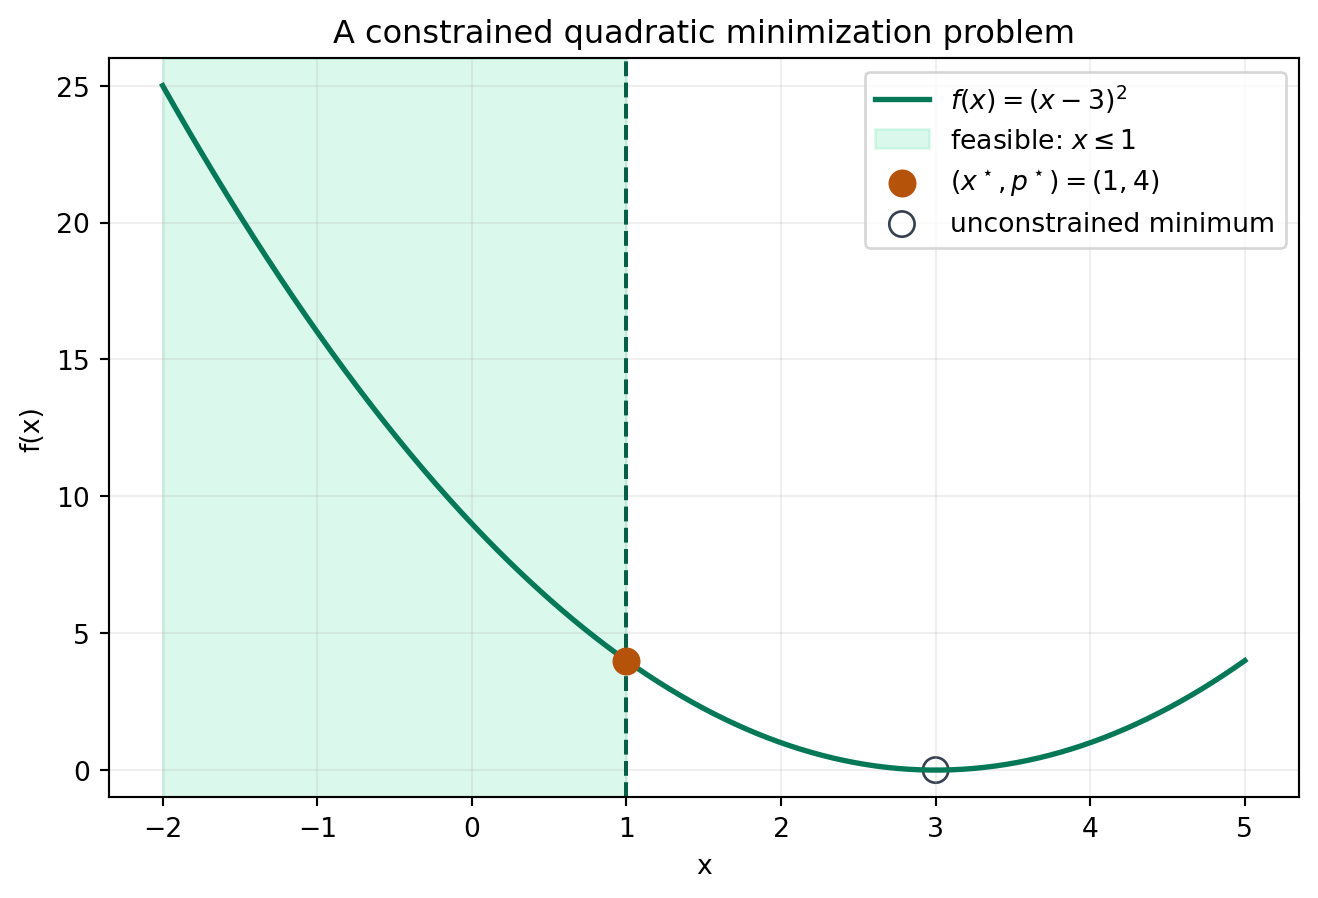

In [2]:
#| label: fig-primal-problem
#| fig-cap: "The constrained minimum occurs where the feasible region ends."

x = np.linspace(-2, 5, 500)
f = (x - 3) ** 2

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, f, color="#047857", linewidth=2, label=r"$f(x)=(x-3)^2$")
ax.axvspan(x.min(), 1, color="#6ee7b7", alpha=0.25, label=r"feasible: $x\leq1$")
ax.axvline(1, color="#065f46", linestyle="--", linewidth=1.5)
ax.scatter([1], [4], color="#b45309", s=90, zorder=4, label=r"$(x^\star,p^\star)=(1,4)$")
ax.scatter([3], [0], facecolors="none", edgecolors="#374151", s=90, label="unconstrained minimum")
ax.set(xlabel="x", ylabel="f(x)", title="A constrained quadratic minimization problem", ylim=(-1, 26))
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## 3. Verify it numerically

A dense grid is not a general optimization algorithm, but it makes a useful check in one dimension.

In [3]:
x_feasible = np.linspace(-10, 1, 20_001)
objective_values = (x_feasible - 3) ** 2
best_index = np.argmin(objective_values)

x_star = x_feasible[best_index]
p_star = objective_values[best_index]
print(f"optimizer x*    = {x_star:.3f}")
print(f"optimal value p* = {p_star:.3f}")

optimizer x*    = 1.000
optimal value p* = 4.000


## 4. What to remember

An optimization problem has an objective, decision variables, and possibly constraints. A constraint can move the optimum away from the unconstrained stationary point and onto the boundary of the feasible set.

In the [next notebook](2.0-primal-and-dual.ipynb), we will recover the same value $p^\star=4$ from a dual maximization problem.

### Exercises

1. Replace the constraint by $x\leq2$. Predict the optimizer before rerunning the code.
2. Replace the constraint by $x\leq4$. Is the constraint active at the solution?
3. Replace the objective by $(x-a)^2$ and describe the optimizer as a function of $a$.